# CodeAlpha Data Science Internship
## Task 1: Iris Flower Classification

**Intern:** Apeksha G Bharadwaj  
**Domain:** Data Science  
**Task:** Iris Flower Classification

## Introduction

The Iris Flower Classification project aims to build a machine learning model that can classify Iris flowers into three species: Setosa, Versicolor, and Virginica.

The classification is performed using four flower measurements: sepal length, sepal width, petal length, and petal width.

1. Import Libraries
2. Load the Iris Dataset
3. Dataset Exploration
4. Data Visualization
5. Feature and Target Selection
6. Train-Test Split
7. Feature Scaling
8. Model Training
9. Predictions
10. Model Accuracy
11. Classification Report
12. Confusion Matrix
13. Actual vs Predicted Species
14. New Flower Prediction
15. Accuracy Visualization
16. Conclusion
17. Technologies Used

In [1]:
# CodeAlpha Data Science Internship
# Task 1: Iris Flower Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the Iris dataset
iris = load_iris()

# Convert the dataset into a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Check the shape of the dataset
print("Shape of dataset:", df.shape)

# Check the column names
print("\nColumn names:")
print(df.columns)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display basic statistical information
print("\nStatistical Summary:")
display(df.describe())

Shape of dataset: (150, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


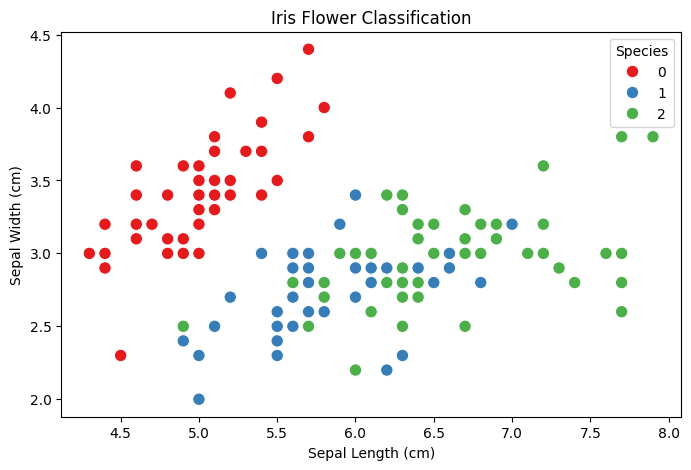

In [4]:
# Visualize the relationship between sepal length and sepal width

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    palette="Set1",
    s=80
)

plt.title("Iris Flower Classification")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title="Species")
plt.show()

In [5]:
# Separate features and target

X = df.drop("species", axis=1)
y = df["species"]

# Display the features
print("Features (X):")
display(X.head())

# Display the target
print("\nTarget (y):")
display(y.head())

# Check their shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y):


,species
0,0
1,0
2,0
3,0
4,0



Shape of X: (150, 4)
Shape of y: (150,)


In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


In [7]:
# Standardize the feature values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

print("\nTesting data after scaling:")
print(X_test_scaled[:5])

Training data after scaling:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]

Testing data after scaling:
[[-1.72156775 -0.10821272 -1.40250384 -1.32327558]
 [ 0.30848902 -0.10821272  0.64163131  0.78343181]
 [-1.12449223 -1.45154306 -0.2668732  -0.26992188]
 [-1.00507713 -1.67543145 -0.2668732  -0.26992188]
 [-1.72156775  0.33956406 -1.40250384 -1.32327558]]


In [8]:
# Create the Logistic Regression model

model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [9]:
# Make predictions on the test data

y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test.to_numpy())

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [10]:
# Calculate the accuracy of the model

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.9333333333333333
Model Accuracy (%): 93.33333333333333


In [11]:
# Generate classification report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



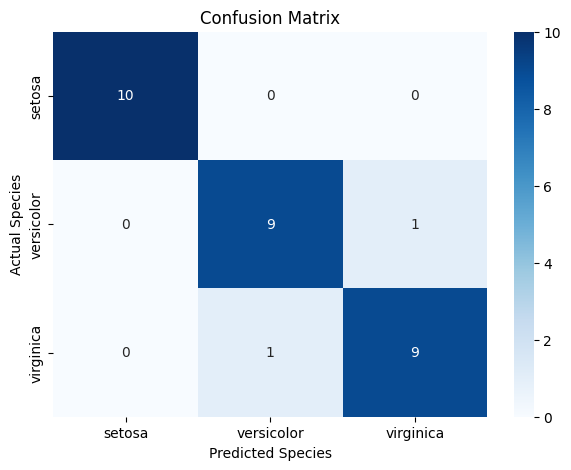

In [12]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

In [13]:
# Convert numerical predictions into flower names

actual_species = [iris.target_names[i] for i in y_test]
predicted_species = [iris.target_names[i] for i in y_pred]

# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Actual Species": actual_species,
    "Predicted Species": predicted_species
})

display(comparison.head(10))

,Actual Species,Predicted Species
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [14]:
# Test the model with a new flower

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the new flower using the same scaler
new_flower_scaled = scaler.transform(new_flower)

# Predict the species
prediction = model.predict(new_flower_scaled)

# Convert prediction to flower name
predicted_name = iris.target_names[prediction[0]]

print("Predicted Flower Species:", predicted_name)

Predicted Flower Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


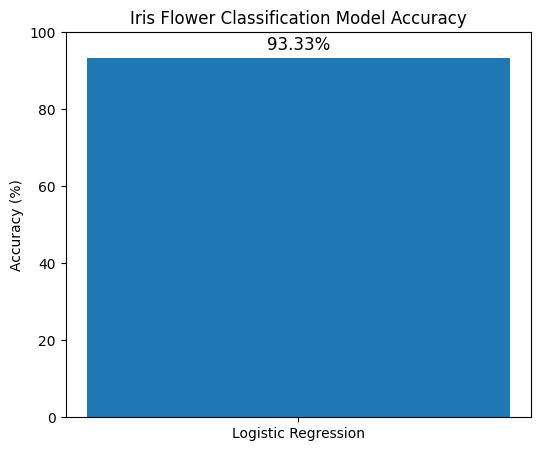

In [15]:
# Visualize model accuracy

accuracy_percentage = accuracy * 100

plt.figure(figsize=(6, 5))

plt.bar(["Logistic Regression"], [accuracy_percentage])

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Iris Flower Classification Model Accuracy")

plt.text(
    0,
    accuracy_percentage + 2,
    f"{accuracy_percentage:.2f}%",
    ha="center",
    fontsize=12
)

plt.show()

## Conclusion

In this project, an Iris Flower Classification model was developed using Python and Scikit-learn. The Iris dataset was explored, cleaned, and divided into training and testing sets. Feature scaling was performed using StandardScaler, and a Logistic Regression model was trained to classify Iris flowers into Setosa, Versicolor, and Virginica species.

The model achieved an accuracy of 93.33% on the test dataset, demonstrating good classification performance. The model was also evaluated using a classification report and confusion matrix. Finally, the trained model was tested with a new flower measurement and successfully predicted its species.

This project helped demonstrate the basic workflow of a machine learning classification problem, including data exploration, preprocessing, model training, prediction, and evaluation.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Logistic Regression
- Google Colab